# Autonomous Hazard-Aware Rover Traverse Planning

### Safely reaching the detected ice: incremental graph search over a physics-informed cost surface

**Problem formulation.** Rover traverse pathfinding is modelled as a graph-search
optimisation over a non-Euclidean cost surface. The objective is to reach the ice
target with minimum cost from a safe landing site, while bounding structural risk
to zero (no traversal of cells whose slope, shadow, or obstacle content would
compromise the rover).

The per-node evaluation function on the 8-connected grid is

$$f(n) = g(n) + h(n) + \omega \cdot \mathrm{Cost_{terrain}}(n)$$

where $g(n)$ is the accumulated path cost, $h(n)$ is an admissible Euclidean
heuristic, $\mathrm{Cost_{terrain}}(n)$ is the local traversal penalty, and
$\omega \ge 0$ weights terrain risk against distance.

**Why D\* Lite over plain A\*.** A planetary rover operates under *partial prior
knowledge*: a coarse orbital map is known in advance, but metre-scale boulders are
only discovered when they enter the onboard sensor horizon (~5 m stereo / LiDAR).
D\* Lite repairs the global path incrementally as hazards appear, at far lower
latency than replanning from scratch.

**Terrain source.** This notebook runs on **real Chandrayaan-2 OHRC** sub-metre
imagery when present, deriving a photometric hazard map (shadows -> pits/steep
interiors; bright high-contrast spots -> boulders; texture -> roughness). A metric
Digital Elevation Model requires stereo photogrammetry (e.g. the NASA Ames Stereo
Pipeline on the overlapping OHRC pair) - noted as future work. If OHRC is absent, a
physically plausible synthetic crater DEM is used instead.


## 1. Setup

In [1]:
import os, sys, glob, time, json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource

PROJECT_ROOT = os.path.abspath(os.getcwd())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src import navigation as nav

os.makedirs("outputs/figures_nav", exist_ok=True)
FIG = "outputs/figures_nav"

ohrc_imgs = sorted(glob.glob("ohrc dataset/**/*_d_img_*.img", recursive=True))
MODE = "ohrc" if ohrc_imgs else "synthetic"
print("terrain mode:", MODE, "| OHRC products found:", len(ohrc_imgs))


terrain mode: ohrc | OHRC products found: 2


## 2. Step 1 - Terrain acquisition

In OHRC mode a window of the real ~0.25 m image is memory-mapped and block-averaged
to a manageable planning grid. The image's lat/lon coverage is reported for
provenance. (Note: this OHRC tile lies ~75 km from the Haworth DFSAR ice target, so
it is used here as representative real lunar terrain for the navigation
demonstration, not as a co-registered overlay - co-registration would require an
OHRC scene over Haworth.)

OHRC: ch2_ohr_ncp_20260103T0410224157_d_img_d18.img
scene coverage: lat [-85.488, -84.676] lon [23.571, 28.311]
planning grid: (200, 200) | 2.00 m/cell | window 400 x 400 m


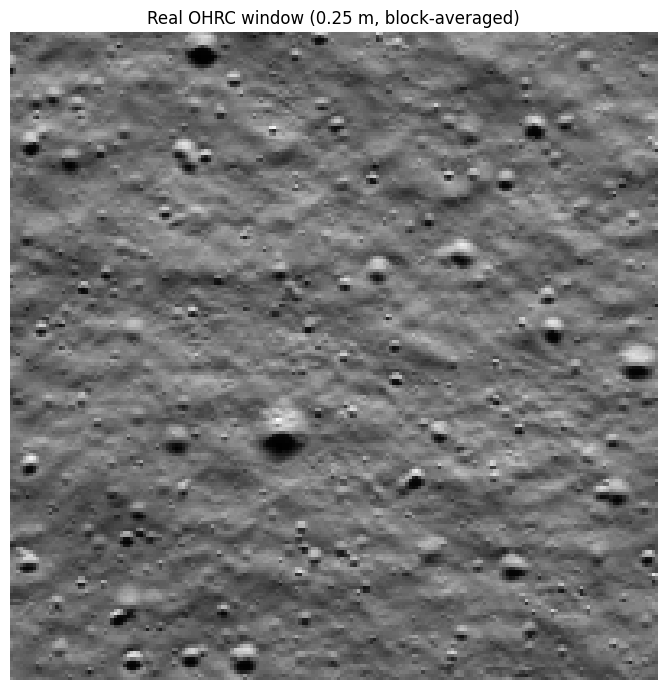

In [2]:
if MODE == "ohrc":
    IMG = ohrc_imgs[0]
    DS = 8                      # block-average factor: 0.25 m -> ~2.0 m/cell
    RES = 0.25 * DS
    img = nav.load_ohrc_window(IMG, line0=10000, samp0=4000,
                               n_lines=1600, n_samps=1600, downsample=DS)
    bg = img                    # grayscale background for plots
    # Provenance from the geometry grid CSV.
    grd = sorted(glob.glob(os.path.dirname(IMG).replace("data", "geometry") + "/*_g_grd_*.csv"))
    grd = grd or glob.glob("ohrc dataset/**/*_g_grd_*.csv", recursive=True)
    a = np.genfromtxt(grd[0], delimiter=",", skip_header=1)
    print("OHRC:", os.path.basename(IMG))
    print("scene coverage: lat [%.3f, %.3f] lon [%.3f, %.3f]"
          % (a[:,1].min(), a[:,1].max(), a[:,0].min(), a[:,0].max()))
    print("planning grid:", img.shape, "| %.2f m/cell | window %.0f x %.0f m"
          % (RES, img.shape[1]*RES, img.shape[0]*RES))
    fig, ax = plt.subplots(figsize=(7, 7)); ax.imshow(img, cmap="gray"); ax.set_title("Real OHRC window (0.25 m, block-averaged)"); ax.axis("off")
    plt.tight_layout(); plt.savefig(FIG+"/terrain_ohrc.png", dpi=150, bbox_inches="tight"); plt.show()
else:
    RES = 1.0
    dem = nav.synthetic_lunar_dem(n=160, resolution_m=RES, seed=1)
    slope = nav.slope_deg_from_dem(dem, RES)
    ls = LightSource(azdeg=315, altdeg=30)
    bg = ls.hillshade(dem, vert_exag=2.0, dx=RES, dy=RES)
    print("synthetic crater DEM", dem.shape, "| %.2f m/cell" % RES)
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    im0 = ax[0].imshow(dem, cmap="terrain"); ax[0].set_title("DEM elevation (m)"); plt.colorbar(im0, ax=ax[0], fraction=0.046)
    im1 = ax[1].imshow(slope, cmap="inferno", vmax=30); ax[1].set_title("slope (deg)"); plt.colorbar(im1, ax=ax[1], fraction=0.046)
    for a_ in ax: a_.axis("off")
    plt.tight_layout(); plt.savefig(FIG+"/terrain_dem.png", dpi=150, bbox_inches="tight"); plt.show()


## 3. Step 2 - Physics-informed costmap translation

**OHRC mode (image-derived hazards):** deep shadows (pits / steep crater interiors)
and bright high-contrast boulders are impassable; local texture (roughness) scales
the traversal cost; smooth regolith is baseline.

**Synthetic mode (DEM-derived):** the terramechanic slope limit applies - for
$\theta \le 15^\circ$ the cost rises as $1 + (e^{\theta/\sigma}-1)$; for
$\theta > 15^\circ$ it is impassable. The $15^\circ$ threshold is the lunar
regolith regime where the wheel-soil slip ratio degrades traction and static
tip-over risk rises sharply. Boulders/micro-craters are impassable.

shadow 6.0% | boulder 0.9% | passable 93.1%


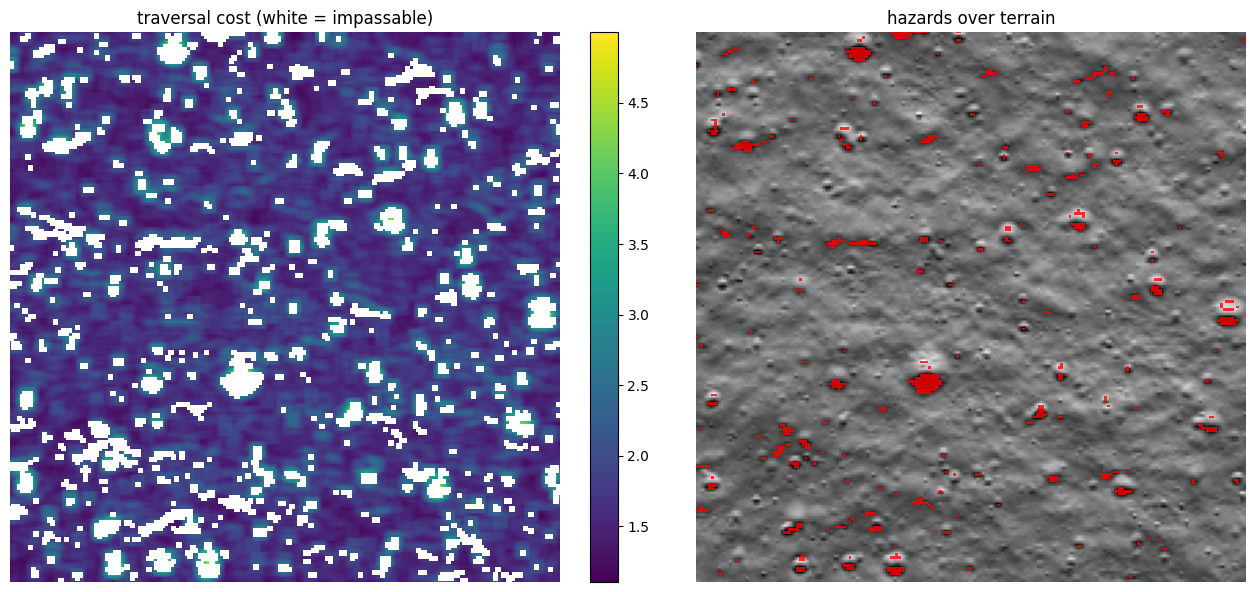

In [3]:
if MODE == "ohrc":
    cm = nav.costmap_from_image(img, shadow_pct=6.0, bright_pct=99.0, roughness_weight=4.0)
    cost = cm["cost"]; hazard = cm["shadow_mask"] | cm["boulder_mask"]
    risk = cm["roughness"]; risk_name = "roughness"
    print("shadow %.1f%% | boulder %.1f%% | passable %.1f%%"
          % (100*cm["shadow_mask"].mean(), 100*cm["boulder_mask"].mean(),
             100*np.isfinite(cost).mean()))
else:
    cm = nav.build_costmap(dem, resolution_m=RES, slope_limit_deg=15.0, obstacle_height_m=0.30)
    cost = cm["cost"]; hazard = cm["obstacle_mask"] | (cm["slope_deg"] > 15.0)
    risk = cm["slope_deg"]; risk_name = "slope_deg"
    print("obstacle %d | slope-blocked %d | passable %.1f%%"
          % (int(cm["obstacle_mask"].sum()), int((cm["slope_deg"]>15).sum()),
             100*np.isfinite(cost).mean()))

passable = np.isfinite(cost)
disp = np.where(passable, cost, np.nan)
fig, ax = plt.subplots(1, 2, figsize=(13, 6))
im0 = ax[0].imshow(disp, cmap="viridis"); ax[0].set_title("traversal cost (white = impassable)"); plt.colorbar(im0, ax=ax[0], fraction=0.046)
ax[1].imshow(bg, cmap="gray"); ax[1].imshow(np.ma.masked_where(~hazard, hazard), cmap="autumn", alpha=0.8)
ax[1].set_title("hazards over terrain")
for a_ in ax: a_.axis("off")
plt.tight_layout(); plt.savefig(FIG+"/costmap.png", dpi=150, bbox_inches="tight"); plt.show()


## 4. Step 3 - Landing-site selection and goal

The **landing site** is a safe, low-cost, hazard-free cell near one edge (the
rover lands on benign terrain and drives in). The **goal** is the ice target from
the DFSAR pipeline; for a co-registered DEM, load `outputs/v3_ice_fraction_geocoded.tif`
and resample it onto this grid. Here the goal is a reachable target cell on the far
side of the scene so the planner must negotiate the real hazard field.

In [4]:
from scipy.ndimage import uniform_filter
H, W = cost.shape
finite_cost = np.where(passable, cost, 10.0)
local_cost = uniform_filter(finite_cost, size=7) + 1e6*(~passable)

# Landing site: safest cell in the top-left approach region.
land_score = local_cost.copy()
land_score[H//3:, :] = np.inf; land_score[:, W//3:] = np.inf
start = np.unravel_index(np.argmin(land_score), land_score.shape)
start = (int(start[0]), int(start[1]))

# Goal: safest cell in the bottom-right region (stands in for the ice target).
goal_score = local_cost.copy()
goal_score[:2*H//3, :] = np.inf; goal_score[:, :2*W//3] = np.inf
goal = np.unravel_index(np.argmin(goal_score), goal_score.shape)
goal = (int(goal[0]), int(goal[1]))
print("landing site:", start, "| goal:", goal, "| both passable:", passable[start], passable[goal])


landing site: (24, 47) | goal: (164, 189) | both passable: True True


## 5. Step 3a - Global baseline plan (A\*)

A\* over the *fully known* cost surface: the performance reference assuming
perfect prior knowledge of every hazard (which a real rover lacks).

In [5]:
res_astar = nav.astar(cost, start, goal, w_terrain=1.0)
print("A* success:", res_astar["success"], "| nodes:", len(res_astar["path"]),
      "| expansions:", res_astar["expansions"], "| time: %.2f s" % res_astar["planning_time_s"])
stats_astar = nav.path_stats(res_astar["path"], cost, risk, RES)
print("A* path: length %.1f m | max %s %.2f | mean %s %.2f"
      % (stats_astar["length_m"], risk_name, stats_astar["max_slope_deg"],
         risk_name, stats_astar["mean_slope_deg"]))


A* success: True | nodes: 162 | expansions: 24830 | time: 0.98 s
A* path: length 422.2 m | max roughness 0.29 | mean roughness 0.15


## 6. Step 3b - Incremental hazard-aware execution (D\* Lite)

The rover begins knowing only the large-scale terrain (shadows visible from orbit)
but **not** where the metre-scale boulders are. It reveals true cell costs within a
5 m sensor horizon and replans incrementally with D\* Lite as boulders appear.

In [6]:
prior = np.where(passable, 1.0, 1.0).astype(float)
if MODE == "ohrc":
    prior[cm["shadow_mask"]] = np.inf          # shadows visible from orbit
    # boulders unknown -> optimistically passable until sensed
else:
    prior = cost.copy(); prior[cm["obstacle_mask"]] = 1.0   # rocks unknown
    prior[cm["slope_deg"] > 15.0] = np.inf                  # slope known from DEM

SENSOR_M = 5.0
sim = nav.simulate_traverse(cost, start, goal, sensor_radius=SENSOR_M,
                            w_terrain=1.0, prior_cost=prior)
print("D* Lite reached goal:", sim["reached_goal"], "| executed nodes:", len(sim["path"]))
print("replans:", sim["replans"], "| expansions:", sim["expansions"],
      "| execution time: %.2f s" % sim["exec_time_s"])
stats_dstar = nav.path_stats(sim["path"], cost, risk, RES)
print("D* Lite path: length %.1f m | max %s %.2f | mean %s %.2f"
      % (stats_dstar["length_m"], risk_name, stats_dstar["max_slope_deg"],
         risk_name, stats_dstar["mean_slope_deg"]))


D* Lite reached goal: True | executed nodes: 163
replans: 163 | expansions: 15145 | execution time: 7.37 s
D* Lite path: length 425.1 m | max roughness 0.37 | mean roughness 0.17


## 7. Quantitative comparison

planner                         length_m      max_risk     mean_risk    expansions       replans  energy_proxy
A* (full prior knowledge)         422.24          0.29          0.15      24830.00          0.00        551.26
D* Lite (sensor horizon)          425.07          0.37          0.17      15145.00        163.00        573.14


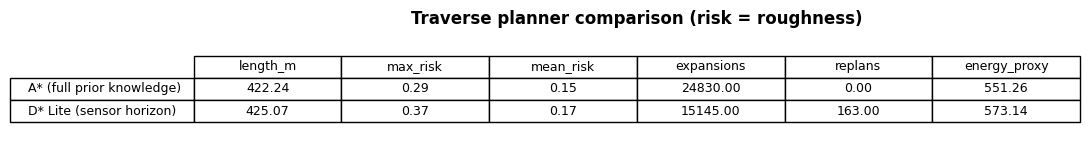

saved outputs/nav_comparison.json


In [7]:
def energy_proxy(path, risk_layer, res):
    if len(path) < 2: return 0.0
    return float(sum(nav._euclid(path[i], path[i+1]) * res *
                     (1.0 + 2.0*risk_layer[path[i+1]]) for i in range(len(path)-1)))

rows = {
    "A* (full prior knowledge)": {
        "length_m": stats_astar["length_m"], "max_risk": stats_astar["max_slope_deg"],
        "mean_risk": stats_astar["mean_slope_deg"], "expansions": res_astar["expansions"],
        "replans": 0, "energy_proxy": energy_proxy(res_astar["path"], risk, RES)},
    "D* Lite (sensor horizon)": {
        "length_m": stats_dstar["length_m"], "max_risk": stats_dstar["max_slope_deg"],
        "mean_risk": stats_dstar["mean_slope_deg"], "expansions": sim["expansions"],
        "replans": sim["replans"], "energy_proxy": energy_proxy(sim["path"], risk, RES)},
}
keys = ["length_m", "max_risk", "mean_risk", "expansions", "replans", "energy_proxy"]
print("%-26s" % "planner", *["%13s" % k for k in keys])
for name, r in rows.items():
    print("%-26s" % name, *["%13.2f" % r[k] for k in keys])

fig, ax = plt.subplots(figsize=(11, 1.6)); ax.axis("off")
cell = [["%.2f" % rows[m][k] for k in keys] for m in rows]
tbl = ax.table(cellText=cell, rowLabels=list(rows.keys()), colLabels=keys, loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.6)
ax.set_title("Traverse planner comparison (risk = %s)" % risk_name, fontweight="bold", pad=10)
plt.tight_layout(); plt.savefig(FIG+"/comparison.png", dpi=150, bbox_inches="tight"); plt.show()
with open("outputs/nav_comparison.json", "w") as f:
    json.dump({"mode": MODE, "rows": rows}, f, indent=2)
print("saved outputs/nav_comparison.json")


## 8. Traverse visualisation

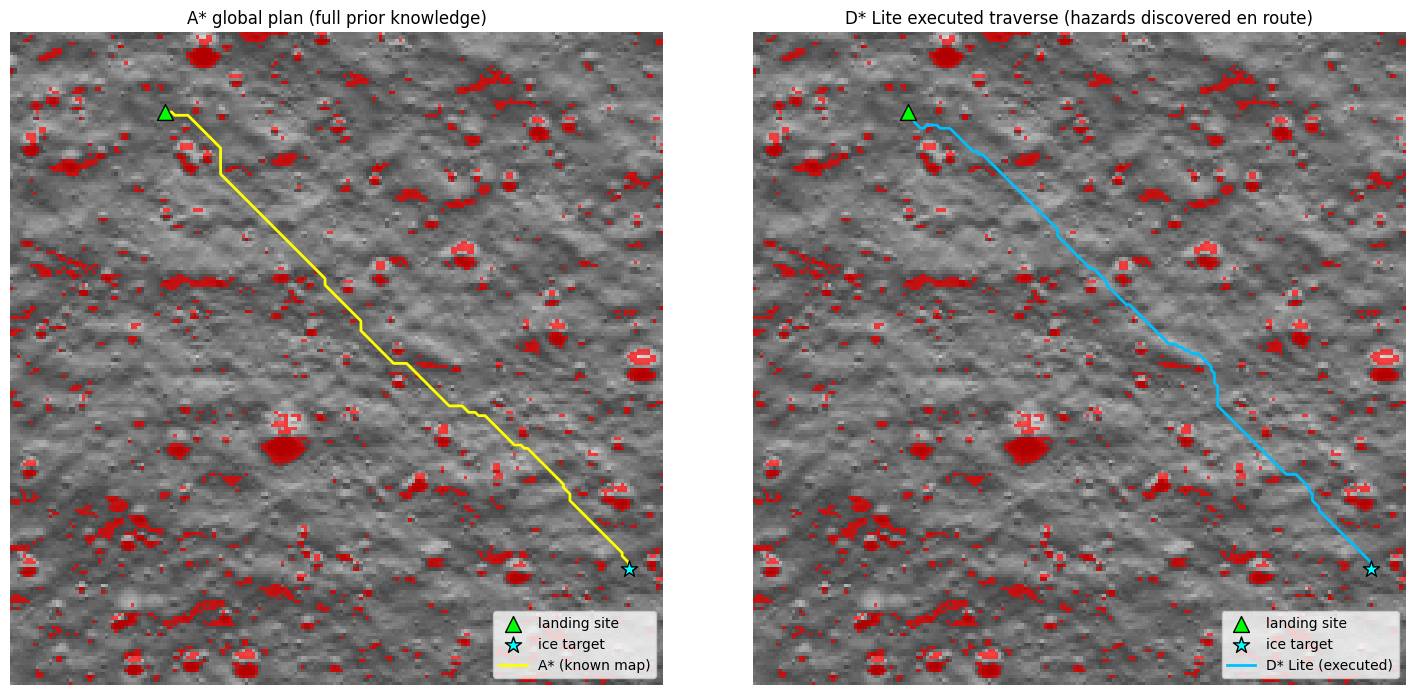

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
for a_ in ax:
    a_.imshow(bg, cmap="gray")
    a_.imshow(np.ma.masked_where(~hazard, hazard), cmap="autumn", alpha=0.7)
    a_.scatter([start[1]], [start[0]], c="lime", s=130, marker="^", label="landing site", zorder=5, edgecolor="k")
    a_.scatter([goal[1]], [goal[0]], c="cyan", s=150, marker="*", label="ice target", zorder=5, edgecolor="k")
    a_.axis("off")
if res_astar["path"]:
    pa = np.array(res_astar["path"]); ax[0].plot(pa[:,1], pa[:,0], "-", c="yellow", lw=2, label="A* (known map)")
ax[0].set_title("A* global plan (full prior knowledge)"); ax[0].legend(loc="lower right")
if sim["path"]:
    pd = np.array(sim["path"]); ax[1].plot(pd[:,1], pd[:,0], "-", c="deepskyblue", lw=2, label="D* Lite (executed)")
ax[1].set_title("D* Lite executed traverse (hazards discovered en route)"); ax[1].legend(loc="lower right")
plt.tight_layout(); plt.savefig(FIG+"/traverse.png", dpi=150, bbox_inches="tight"); plt.show()
